In [10]:
#Imports and directory
import os
import pickle
import random
import math
import numpy as np
import pandas as pd
import matplotlib
import torch
import torch.nn as nn
import optuna
from matplotlib import pyplot as plt
os.chdir("/home/ec2-user/CS-230-Deep-Learning-Project")
#os.chdir(r"C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project")

In [11]:
# Basic functions including device and seeding
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print("USING DEVICE:", device)

def save_object_to_file(obj, filepath):
    with open(filepath, "wb") as f:
        pickle.dump(obj, f)

def read_object_from_file(filepath):
    with open(filepath, "rb") as f:
        return pickle.load(f)

def seed_everything(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


USING DEVICE: cpu


In [12]:
# --- Data preparation ---
DATA_CSV_FR = os.path.join("data", "FR_LMP_Forecasts", "FR_lmp_processed.csv")
DATA_CSV_LOAD = os.path.join("data", "FR_DAM_Load_Forecasts", "FR_load_processed.csv")
DATA_CSV_REN = os.path.join("data", "FR_REN_DAM_Forecasts", "FR_ren_processed.csv")
DATA_CSV_LOAD_RT=os.path.join("data", "FR_DAM_Load_Forecasts", "FR_rt_load_processed.csv")
DATA_CSV_REN_RT=os.path.join("data", "FR_REN_DAM_Forecasts", "FR_rt_ren_processed.csv")
def split_data(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
    train = df[(df['date'] >= '2019-10-01') & (df['date'] <= '2023-09-30')].reset_index(drop=True)
    dev   = df[(df['date'] >= '2023-10-01') & (df['date'] <= '2024-09-30')].reset_index(drop=True)
    test  = df[(df['date'] >= '2024-10-01') & (df['date'] <= '2025-09-30')].reset_index(drop=True)
    return train, dev, test


In [4]:
df_FR = pd.read_csv(DATA_CSV_FR)
load_FR = pd.read_csv(DATA_CSV_LOAD)
ren_FR = pd.read_csv(DATA_CSV_REN)
all_data_DA = pd.merge(df_FR, load_FR, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_DA = pd.merge(all_data_DA, ren_FR, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_DA.rename(columns={'MW':'Load_DA','Wind Onshore':'Wind_DA','Solar':'Solar_DA'}, inplace=True)
load_FR_rt = pd.read_csv(DATA_CSV_LOAD_RT)
ren_FR_rt = pd.read_csv(DATA_CSV_REN_RT)
all_data_RT = pd.merge(df_FR, load_FR_rt, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_RT = pd.merge(all_data_RT, ren_FR_rt, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_RT.rename(columns={'MW':'Load_RT','Wind Onshore':'Wind_RT','Solar':'Solar_RT'}, inplace=True)

all_data=pd.merge(all_data_DA,all_data_RT,on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour','EUR/MWh'], how='inner')
all_data

,Time,Year,Month,Day,Hour,Timezone,EUR/MWh,Load_DA,Wind_DA,Solar_DA,Load_RT,Wind_RT,Solar_RT
0,2019-10-01 00:00:00+02:00,2019,10,1,0,+02:00,33.09,44450.0,4975.31,0.00,43062.00,6076.00,0.00
1,2019-10-01 01:00:00+02:00,2019,10,1,1,+02:00,27.72,41300.0,5338.58,0.00,40483.00,6137.00,0.00
2,2019-10-01 02:00:00+02:00,2019,10,1,2,+02:00,23.12,40050.0,5702.33,0.00,39207.00,6342.00,0.00
3,2019-10-01 03:00:00+02:00,2019,10,1,3,+02:00,16.46,37750.0,5667.94,0.00,37004.00,6355.00,0.00
4,2019-10-01 04:00:00+02:00,2019,10,1,4,+02:00,15.66,36600.0,5633.30,0.00,36399.00,6217.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
52142,2025-09-30 19:00:00+02:00,2025,9,30,19,+02:00,117.00,49000.0,2435.69,2158.72,49421.41,1939.43,901.85
52143,2025-09-30 20:00:00+02:00,2025,9,30,20,+02:00,106.18,50400.0,2929.19,315.89,50315.77,2445.66,244.45
52144,2025-09-30 21:00:00+02:00,2025,9,30,21,+02:00,83.23,46700.0,3480.47,0.00,47039.08,3116.56,0.00
52145,2025-09-30 22:00:00+02:00,2025,9,30,22,+02:00,73.00,44100.0,3879.11,0.00,45544.52,3422.12,0.00


In [13]:

#Normalization and splitting
train_df_FR, dev_df_FR, test_df_FR = split_data(all_data)


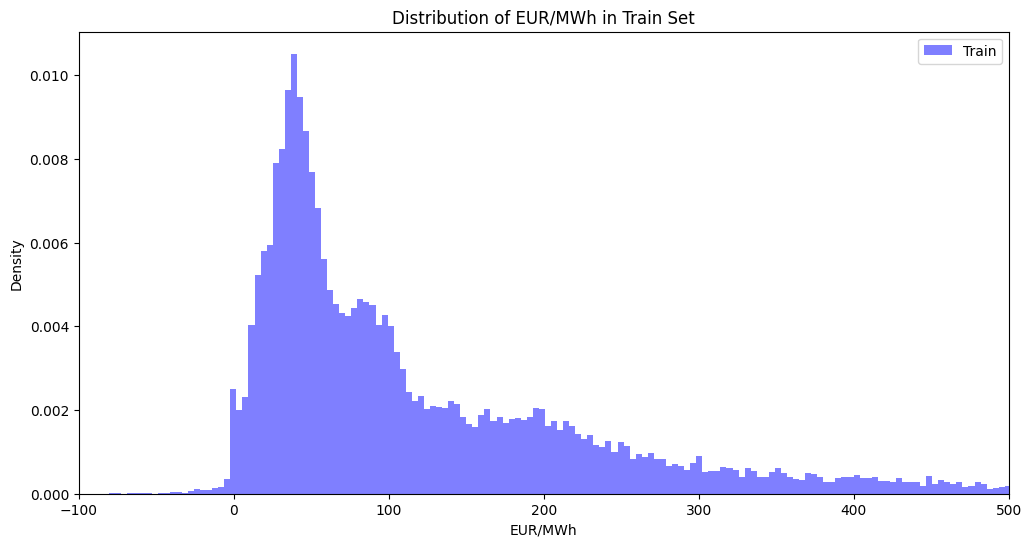

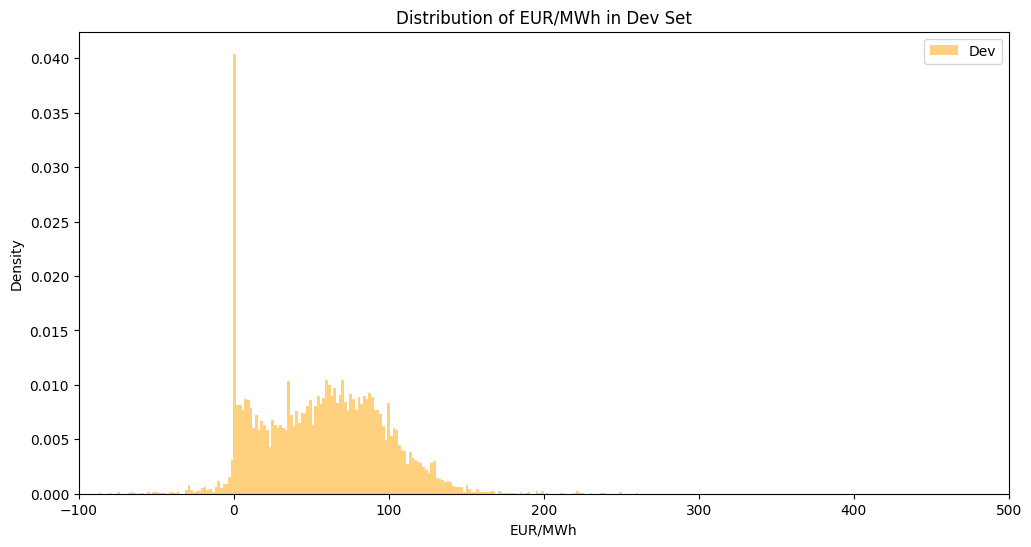

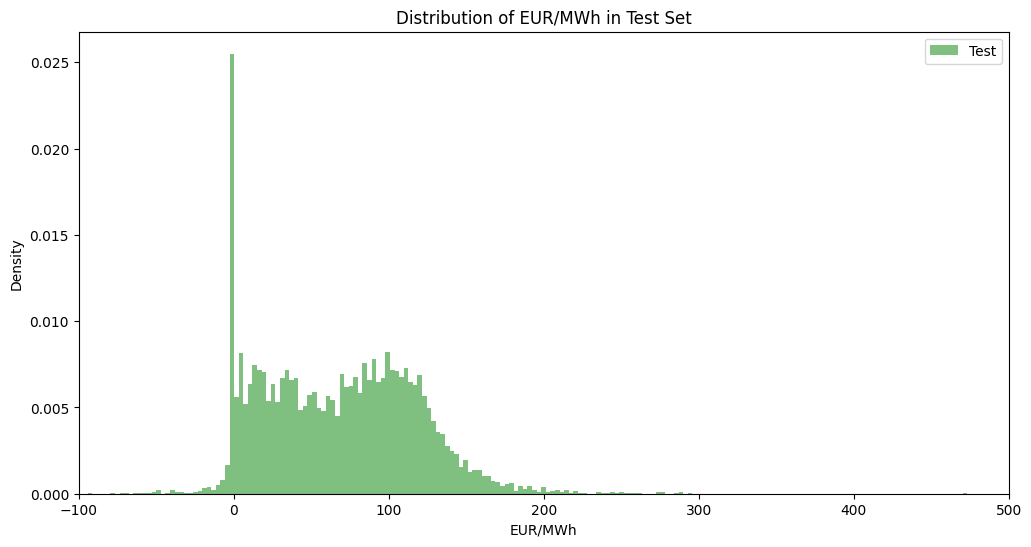

In [14]:
#Plot the distributions of train, dev, test sets on separate histograms
plt.figure(figsize=(12, 6))
plt.hist(train_df_FR['EUR/MWh'], bins=800, alpha=0.5, label='Train', color='blue', density=True)
plt.title('Distribution of EUR/MWh in Train Set')
plt.xlabel('EUR/MWh')
plt.ylabel('Density')
plt.xlim(-100, 500)
plt.legend()
plt.show()
plt.figure(figsize=(12, 6))
plt.hist(dev_df_FR['EUR/MWh'], bins=200, alpha=0.5, label='Dev', color='orange', density=True)
plt.title('Distribution of EUR/MWh in Dev Set')
plt.xlabel('EUR/MWh')
plt.ylabel('Density')
plt.xlim(-100, 500)
plt.legend()
plt.show()
plt.figure(figsize=(12, 6))
plt.hist(test_df_FR['EUR/MWh'], bins=200, alpha=0.5, label='Test', color='green', density=True)
plt.xlabel('EUR/MWh')
plt.ylabel('Density')
plt.title('Distribution of EUR/MWh in Test Set')
plt.xlim(-100, 500)
plt.legend()
plt.show()


In [ ]:


def normalize_dataset(train_df, dev_df, test_df):
    
    normalization_params = {}

    # --- 1. Target normalization (price) ---
    target = "EUR/MWh"
    mean_price = train_df[target].mean()
    std_price = train_df[target].std()
    normalization_params[target] = {"mean": mean_price, "std": std_price}

    for df in [train_df, dev_df, test_df]:
        df[target] = (df[target] - mean_price) / std_price

    # --- 2. Variables that exist in DA and RT versions ---
    paired_vars = ["Load", "Wind", "Solar"]

    for var in paired_vars:
        da_col = f"{var}_DA"
        rt_col = f"{var}_RT"

        # compute joint stats over DA + RT (train only)
        mean_val = pd.concat([train_df[da_col], train_df[rt_col]]).mean()
        std_val = pd.concat([train_df[da_col], train_df[rt_col]]).std()

        normalization_params[var] = {"mean": mean_val, "std": std_val}

        # apply normalization to all splits
        for df in [train_df, dev_df, test_df]:
            df[da_col] = (df[da_col] - mean_val) / std_val
            df[rt_col] = (df[rt_col] - mean_val) / std_val

    return train_df, dev_df, test_df, normalization_params


train_df_FR, dev_df_FR, test_df_FR, normalization_params_FR = normalize_dataset(train_df_FR, dev_df_FR, test_df_FR)


In [32]:
train_df_FR

,Time,Year,Month,Day,Hour,Timezone,EUR/MWh,Load_DA,Wind_DA,Solar_DA,Load_RT,Wind_RT,Solar_RT,date
0,2019-10-01 00:00:00+02:00,2019,10,1,0,+02:00,-0.736690,-0.596067,0.205316,-0.686955,-0.718598,0.561935,-0.686955,2019-10-01
1,2019-10-01 01:00:00+02:00,2019,10,1,1,+02:00,-0.779027,-0.874145,0.323014,-0.686955,-0.946269,0.581699,-0.686955,2019-10-01
2,2019-10-01 02:00:00+02:00,2019,10,1,2,+02:00,-0.815294,-0.984494,0.440867,-0.686955,-1.058913,0.648118,-0.686955,2019-10-01
3,2019-10-01 03:00:00+02:00,2019,10,1,3,+02:00,-0.867801,-1.187535,0.429725,-0.686955,-1.253392,0.652330,-0.686955,2019-10-01
4,2019-10-01 04:00:00+02:00,2019,10,1,4,+02:00,-0.874108,-1.289056,0.418502,-0.686955,-1.306800,0.607618,-0.686955,2019-10-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34605,2023-09-30 19:00:00+02:00,2023,9,30,19,+02:00,0.043352,-0.882973,-1.092628,-0.456552,-0.947329,-1.097896,0.119480,2023-09-30
34606,2023-09-30 20:00:00+02:00,2023,9,30,20,+02:00,-0.017749,-0.768211,-1.084651,-0.686955,-0.800344,-1.109560,-0.531121,2023-09-30
34607,2023-09-30 21:00:00+02:00,2023,9,30,21,+02:00,-0.200816,-0.949182,-0.996352,-0.686955,-0.806524,-1.090120,-0.686955,2023-09-30
34608,2023-09-30 22:00:00+02:00,2023,9,30,22,+02:00,-0.150831,-1.033047,-0.907500,-0.686955,-0.982287,-1.015601,-0.686955,2023-09-30


In [33]:
#Create sliding windows

window_days = 7
forecast_horizon = 24
def create_aligned_windows(df,
                           past_feature_cols,
                           future_feature_cols,
                           target_col="EUR/MWh",
                           window_days=7,
                           forecast_horizon=24):
    # prepare
    hours = 24
    past_window = window_days * hours
    values = df.copy().reset_index(drop=True)
    vals = values.values
    cols = values.columns

    # index maps
    past_idx = [cols.get_loc(c) for c in past_feature_cols]
    fut_idx  = [cols.get_loc(c) for c in future_feature_cols]
    tgt_idx  = cols.get_loc(target_col)

    max_start = len(values) - past_window - forecast_horizon + 1   # +1 to include last valid start
    X_seq = []
    X_dnn = []
    starts = []   # store start timestamps for debugging/traceability

    for i in range(max_start):
        X_seq.append(vals[i : i + past_window, past_idx])                      # (168, k_past)
        X_dnn.append(vals[i + past_window : i + past_window + forecast_horizon, fut_idx])  # (24, k_future)
        starts.append(values.loc[i, 'Date'] if 'Date' in values.columns else i)

    return np.array(X_seq, dtype=np.float32), np.array(X_dnn, dtype=np.float32), starts


def create_targets(df, target_col="EUR/MWh", window_days=7, forecast_horizon=24):
    """
    Creates next-24-hour targets aligned with LSTM windows.
    """
    hours = 24
    window_size = window_days * hours
    series = df[target_col].values

    y = []
    y_day_before = []
    y_week_before = []

    for i in range(len(series) - window_size - forecast_horizon + 1):

                # Target: next `forecast_horizon` hours
        y_target = series[i + window_size : i + window_size + forecast_horizon]

        # --- Naive baselines ---
        # previous day
        if i - hours >= 0:
            y_prev_day = series[i + window_size - hours : i + window_size - hours + forecast_horizon]
        else:
            y_prev_day = np.full(forecast_horizon, np.nan)

        # previous week
        if i - 7 * hours >= 0:
            y_prev_week = series[i + window_size - 7 * hours : i + window_size - 7 * hours + forecast_horizon]
        else:
            y_prev_week = np.full(forecast_horizon, np.nan)

        
        y.append(y_target)
        y_day_before.append(y_prev_day)
        y_week_before.append(y_prev_week)

    return np.array(y, dtype=np.float32), np.array(y_day_before, dtype=np.float32), np.array(y_week_before, dtype=np.float32)



In [34]:
#Convert hour, day, month into cyclic features
def add_cyclical_features(df):
    df['Date']=pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour']])
    df["DayOfWeek"] = df['Date'].dt.dayofweek
    # Hour of day (0-23)
    df["sin_hour"] = np.sin(2 * np.pi * df["Hour"] / 24)
    df["cos_hour"] = np.cos(2 * np.pi * df["Hour"] / 24)

    # Day of week (0-6 or 1-7 depending on your data)
    df["sin_day"] = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
    df["cos_day"] = np.cos(2 * np.pi * df["DayOfWeek"] / 7)

    # Month (1-12)
    df["sin_month"] = np.sin(2 * np.pi * df["Month"] / 12)
    df["cos_month"] = np.cos(2 * np.pi * df["Month"] / 12)
    return df


In [35]:
#Add cyclical features to datasets
train_df_FR = add_cyclical_features(train_df_FR)
dev_df_FR = add_cyclical_features(dev_df_FR)
test_df_FR = add_cyclical_features(test_df_FR)
past_features = [
    'EUR/MWh',          # past prices
    'Load_RT',               # load
    'Wind_RT',     # wind
    'Solar_RT',            # solar
    'sin_hour', 'cos_hour',
    'sin_day',  'cos_day',
    'sin_month','cos_month'
]
future_features = [
    'Load_DA',               # load
    'Wind_DA',     # wind
    'Solar_DA',            # solar
    'sin_hour', 'cos_hour',
    'sin_day',  'cos_day',
    'sin_month','cos_month'
]
X_seq_train, X_dnn_train, starts_train = create_aligned_windows(
    train_df_FR,
    past_feature_cols=past_features,         # e.g. 10 past features
    future_feature_cols=future_features,         # e.g. ['Load_DA','Solar_DA','Wind_DA','sin_hour','cos_hour','sin_doy','cos_doy']
    target_col='EUR/MWh',
    window_days=7, forecast_horizon=24
)
X_seq_dev, X_dnn_dev, starts_dev = create_aligned_windows(
    dev_df_FR,
    past_feature_cols=past_features,         # e.g. 10 past features
    future_feature_cols=future_features,         #  e.g. ['Load_DA','Solar_DA','Wind_DA','sin_hour','cos_hour','sin_doy','cos_doy']
    target_col='EUR/MWh',
    window_days=7, forecast_horizon=24
)
X_seq_test, X_dnn_test, starts_test = create_aligned_windows(
    test_df_FR,
    past_feature_cols=past_features,         # e.g. 10 past features
    future_feature_cols=future_features,         # e.g. ['Load_DA','Solar_DA','Wind_DA','sin_hour','cos_hour','sin_doy','cos_doy']
    target_col='EUR/MWh',
    window_days=7, forecast_horizon=24
)
y_train,y_train_1d, y_train_7d = create_targets(train_df_FR)
y_dev, y_dev_1d, y_dev_7d = create_targets(dev_df_FR)
y_test, y_test_1d, y_test_7d = create_targets(test_df_FR)



In [36]:
print("Shape of the LSTM inputs",X_seq_train.shape)
print("Shape of the DNN inputs",X_dnn_train.shape)
print("Shape of targets",y_train.shape)
print("Shape of 1-day before targets",y_train_1d.shape)
print("Shape of 7-day before targets",y_train_7d.shape)

Shape of the LSTM inputs (34419, 168, 10)
Shape of the DNN inputs (34419, 24, 9)
Shape of targets (34419, 24)
Shape of 1-day before targets (34419, 24)
Shape of 7-day before targets (34419, 24)


In [37]:

# MAE loss (matches TF mae)
def mae_loss_fn(pred, target):
    return torch.mean(torch.abs(pred - target))


In [38]:
def evaluate_model(
    model,
    X_seq_np,
    X_dnn_np,
    y_np, y_np_1d, y_np_7d,
    std_FR, mean_FR,
    shift=7*24,
    batch_size=128,
    device="cpu"
):
    """
    Evaluate an LSTM+DNN model that predicts a 24-h horizon.
    """

    # -----------------------------------
    # Sanity checks
    # -----------------------------------
    if X_dnn_np is None:
        raise ValueError("X_dnn_np cannot be None for a hybrid LSTM+DNN model.")

    N = len(X_seq_np)
    assert len(X_dnn_np) == N, "Mismatch: X_seq and X_dnn have different lengths"
    assert len(y_np) == N, "Mismatch between X and y"

    # -----------------------------------
    # Move model to device
    # -----------------------------------
    model = model.to(device)
    model.eval()

    preds_list = []

    # -----------------------------------
    # Predict in batches (GPU-safe)
    # -----------------------------------
    with torch.no_grad():
        for i in range(0, N, batch_size):
            xb_seq = torch.from_numpy(X_seq_np[i:i+batch_size]).float().to(device)

            xb_dnn = (
                torch.from_numpy(X_dnn_np[i:i+batch_size]).float().to(device)
                if X_dnn_np is not None else None
            )

            out = model(xb_seq, xb_dnn)

            preds_list.append(out.cpu().numpy())

    # All predictions stacked
    predictions = np.concatenate(preds_list, axis=0)

    # -----------------------------------
    # Denormalize
    # -----------------------------------
    predictions = predictions * std_FR + mean_FR
    y_np       = y_np       * std_FR + mean_FR
    y_np_1d    = y_np_1d    * std_FR + mean_FR
    y_np_7d    = y_np_7d    * std_FR + mean_FR

    # -----------------------------------
    # 1. Standard MAE
    # -----------------------------------
    mae_model = np.mean(np.abs(predictions - y_np))

    median_val = np.median(y_np)
    mae_median = np.mean(np.abs(median_val - y_np))
    maem = mae_model / mae_median

    # -----------------------------------
    # 2. rMAE (1-day shift)
    # -----------------------------------
    preds_1d  = predictions[24:]
    target_1d = y_np[24:]
    naive_1d  = y_np_1d[24:]

    mae_model_1d = np.mean(np.abs(preds_1d - target_1d))
    mae_naive_1d = np.mean(np.abs(naive_1d - target_1d))
    rMAE_1d = mae_model_1d / mae_naive_1d

    # -----------------------------------
    # 3. rMAE (7-day shift)
    # -----------------------------------
    if len(y_np) <= shift:
        raise ValueError(f"Need more than {shift} samples for 7-day rMAE.")

    preds_7d  = predictions[shift:]
    target_7d = y_np[shift:]
    naive_7d  = y_np_7d[shift:]

    mae_model_7d = np.mean(np.abs(preds_7d - target_7d))
    mae_naive_7d = np.mean(np.abs(naive_7d - target_7d))
    rMAE_7d = mae_model_7d / mae_naive_7d

    # -----------------------------------
    # sMAPE
    # -----------------------------------
    sMAPE = np.mean(
        2 * np.abs(predictions - y_np) / (np.abs(predictions) + np.abs(y_np) + 1e-8)
    ) * 100  # in percentage

    # -----------------------------------
    # Print summary
    # -----------------------------------
    print(
        f"MAE: {mae_model:.6f} | "
        f"MAEm: {maem:.6f} | "
        f"rMAE (1d): {rMAE_1d:.6f} | "
        f"rMAE (7d): {rMAE_7d:.6f} | "
        f"sMAPE: {sMAPE:.6f}%"
    )

    return {
        "predictions": predictions,
        "MAE": mae_model,
        "MAEm": maem,
        "rMAE (1 day)": rMAE_1d,
        "rMAE (7 days)": rMAE_7d,
        "sMAPE": sMAPE
    }


In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class RNN(nn.Module):
    def __init__(
        self,
        n_features,
        seq_len,
        output_dim,
        hidden_size=128,
        num_layers=2,
        dropout=0.2,
        use_batchnorm=True,
        leaky_alpha=0.1,
        future_dim=None,
        future_horizon=None
    ):
        super().__init__()

        self.seq_len = seq_len
        self.n_features = n_features
        self.output_dim = output_dim
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.use_batchnorm = use_batchnorm
        self.leaky_alpha = leaky_alpha

        # --- store dropout PROBABILITY ---
        self.dropout_p = dropout

        # --------------------- LSTM BRANCH ---------------------
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )

        # Standard dropout layer for LSTM output and MLP
        self.dropout = nn.Dropout(dropout)

        # future_dense built lazily
        self.future_dim = future_dim
        self.future_horizon = future_horizon
        self.future_dense = None  

        # --------------------- FINAL MLP ---------------------
        self.fc1 = nn.Linear(hidden_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_dim)

        if use_batchnorm:
            self.bn_lstm = nn.BatchNorm1d(hidden_size)
            self.bn_fc1 = nn.BatchNorm1d(hidden_size)


    # --------------------------------------------------------------
    def build_future_module(self):
        """Builds the DNN for future inputs once sizes are known."""
        fut_input_size = self.future_dim * self.future_horizon
        
        self.future_dense = nn.Sequential(
            nn.Linear(fut_input_size, self.hidden_size),
            nn.LeakyReLU(self.leaky_alpha),
            nn.Dropout(self.dropout_p),     # FIXED DROPOUT
            
            nn.Linear(self.hidden_size, self.hidden_size),
            nn.LeakyReLU(self.leaky_alpha)
        )

        # Move new module to same device as rest of model
        self.future_dense.to(next(self.parameters()).device)


    # --------------------------------------------------------------
    def forward(self, seq_x, future_x=None):
        """
        seq_x:    (B, seq_len, n_features)
        future_x: (B, future_horizon, future_dim)
        """

        device = next(self.parameters()).device
        seq_x = seq_x.to(device)
        if future_x is not None:
            future_x = future_x.to(device)

        # Build future network on-the-fly if needed
        if future_x is not None and self.future_dense is None:
            self.future_dim = future_x.shape[-1]
            self.future_horizon = future_x.shape[1]
            self.build_future_module()

        # --------------------- LSTM BRANCH ---------------------
        lstm_out, (h, _) = self.lstm(seq_x)
        h = h[-1]   # final hidden state (B, hidden_size)

        if self.use_batchnorm:
            h = self.bn_lstm(h)

        h = F.leaky_relu(h, negative_slope=self.leaky_alpha)
        h = self.dropout(h)

        # --------------------- FUTURE BRANCH ---------------------
        if future_x is not None and self.future_dense is not None:
            B = future_x.shape[0]
            fut = future_x.reshape(B, -1)
            fut = self.future_dense(fut)

            x = h + fut        # skip-like fusion
        else:
            x = h

        # --------------------- FINAL MLP ---------------------
        x = self.fc1(x)
        if self.use_batchnorm:
            x = self.bn_fc1(x)

        x = F.leaky_relu(x, negative_slope=self.leaky_alpha)
        x = self.dropout(x)

        return self.fc2(x)


In [40]:
def run_full_train(
    X_seq_train, X_dnn_train, y_train,
    X_seq_dev,   X_dnn_dev,   y_dev,
    hidden_size=128,
    num_layers=2,
    dropout=0.2,
    use_batchnorm=True,
    leaky_alpha=0.1,
    learning_rate=1e-3,
    weight_decay=0.0,
    l1_lambda=0.0,
    batch_size=128,
    epochs=20,
    verbose_freq=1,
    device="cuda"
):

    # -------------------------
    # Convert to tensors
    # -------------------------
    X_seq_train_t = torch.from_numpy(X_seq_train).float()
    X_seq_dev_t   = torch.from_numpy(X_seq_dev).float()

    X_dnn_train_t = torch.from_numpy(X_dnn_train).float() if X_dnn_train is not None else None
    X_dnn_dev_t   = torch.from_numpy(X_dnn_dev).float() if X_dnn_dev is not None else None

    y_train_t = torch.from_numpy(y_train).float()
    y_dev_t   = torch.from_numpy(y_dev).float()

    # -------------------------
    # Build model
    # -------------------------
    model = RNN(
        n_features=X_seq_train.shape[-1],
        seq_len=X_seq_train.shape[1],
        output_dim=y_train.shape[-1],
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        use_batchnorm=use_batchnorm,
        leaky_alpha=leaky_alpha
    ).to(device)

    # Initialize future branch (first batch will auto-build too)
    if X_dnn_train is not None:
        model.future_dim = X_dnn_train.shape[-1]
        model.future_horizon = X_dnn_train.shape[1]
        model.build_future_module()

    # -------------------------
    # Optimizer / loss
    # -------------------------
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    mae_loss = torch.nn.L1Loss()
    print("Model:")
    print(model)
    print("Optimizer:", optimizer)
    print("Batch size:", batch_size, "Epochs:", epochs)
    # -------------------------
    # Training loop
    # -------------------------
    train_hist = []
    val_hist = []

    N = len(X_seq_train)

    for epoch in range(epochs):

        model.train()
        perm = torch.randperm(N)

        train_loss_epoch = 0.0
        num_batches = 0

        for i in range(0, N, batch_size):

            idx = perm[i:i+batch_size]

            seq_b = X_seq_train_t[idx].to(device)
            dnn_b = X_dnn_train_t[idx].to(device) if X_dnn_train_t is not None else None
            y_b   = y_train_t[idx].to(device)

            # Forward
            preds = model(seq_b, dnn_b)
            loss = mae_loss(preds, y_b)

            # L1 penalty (optional)
            if l1_lambda > 0:
                l1 = 0.0
                for p in model.parameters():
                    l1 += p.abs().sum()
                loss += l1_lambda * l1

            # Backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss_epoch += loss.item()
            num_batches += 1

        train_loss_epoch /= num_batches
        train_hist.append(train_loss_epoch)

        # -------------------------
        # VALIDATION (batched MAE)
        # -------------------------
        model.eval()
        with torch.no_grad():
            val_loss = 0.0
            n_val = 0

            for i in range(0, len(X_seq_dev_t), batch_size):

                xb_seq = X_seq_dev_t[i:i+batch_size].to(device)
                xb_dnn = X_dnn_dev_t[i:i+batch_size].to(device) if X_dnn_dev_t is not None else None
                yb     = y_dev_t[i:i+batch_size].to(device)

                pred = model(xb_seq, xb_dnn)

                loss = mae_loss(pred, yb)   # <-- FIXED

                val_loss += loss.item() * xb_seq.size(0)
                n_val += xb_seq.size(0)

            val_loss /= n_val

        val_hist.append(val_loss)



        # -------------------------
        # Logging
        # -------------------------
        if epoch % verbose_freq == 0:
            print(
                f"Epoch {epoch+1:03d} | Train MAE: {train_loss_epoch:.6f} "
                f"| Val MAE: {val_loss:.6f}"
            )

    return model, train_hist, val_hist


In [41]:

# --- Main: load CSV, prepare sliding windows, normalize, quick experiments ---
SEED = 42
seed_everything(SEED)




In [42]:

# experiment config(s) (keeps logic/content from notebook)
all_exp_params = {
    "default": {      
        "hidden_size": 128,
        "num_layers": 2,
        "dropout": 0.39405665798699856,
        "use_batchnorm": True,
        "leaky_alpha": 0.17191592974082023,
        "learning_rate": 0.0001669563793051408,
        "weight_decay": 6.5908013631994725e-06,
        "l1_lambda": 4.668731488278379e-06,
        "batch_size": 256,
        "epochs": 20

    }
}
results_save_path = "rolling_window_exp_results.pkl"
plot_suffix = "_loss_plot.jpg"
exp_results = {}

for tag, params in all_exp_params.items():
    print("Running experiment:", tag)
    model, train_hist, val_hist = run_full_train(
        X_seq_train, X_dnn_train, y_train, X_seq_dev, X_dnn_dev, y_dev,
        hidden_size=params["hidden_size"],
        num_layers=params["num_layers"],
        dropout = params["dropout"],
        use_batchnorm = params["use_batchnorm"],
        leaky_alpha = params["leaky_alpha"],
        learning_rate = params["learning_rate"],
        weight_decay = params["weight_decay"],
        l1_lambda = params.get("l1_lambda", 0.0),
        batch_size = params["batch_size"],
        epochs = params["epochs"],
        verbose_freq = 1
    )
    # evaluate dev set (rMAE etc)
    print("Evaluating on dev set:")
    eval_res = evaluate_model(model, X_seq_dev, X_dnn_dev, y_dev, y_dev_1d, y_dev_7d, std_FR=normalization_params_FR["EUR/MWh"]["std"], mean_FR=normalization_params_FR["EUR/MWh"]["mean"], device=device)
    exp_results[tag] = {"train_loss": train_hist, "val_loss": val_hist, "eval": eval_res}
    
save_object_to_file(exp_results, results_save_path)
exp_results = read_object_from_file(results_save_path)

for tag, r in exp_results.items():
    tr = r["train_loss"]
    va = r["val_loss"]
    plt.clf()
    plt.plot(range(len(tr)), tr, label="Train Loss")
    plt.plot(range(len(va)), va, label="Validation Loss")
    plt.title(f"{tag} Loss vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend(loc="upper right")
    plt.savefig(tag + plot_suffix)
    plt.clf()
plt.show()

Running experiment: default
Model:
RNN(
  (lstm): LSTM(10, 128, num_layers=2, batch_first=True, dropout=0.39405665798699857)
  (dropout): Dropout(p=0.39405665798699857, inplace=False)
  (fc1): Linear(in_features=128, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=24, bias=True)
  (bn_lstm): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn_fc1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (future_dense): Sequential(
    (0): Linear(in_features=216, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.17191592974082023)
    (2): Dropout(p=0.39405665798699857, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): LeakyReLU(negative_slope=0.17191592974082023)
  )
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    f

<Figure size 640x480 with 0 Axes>

In [43]:
std=normalization_params_FR["EUR/MWh"]["std"]
mean=normalization_params_FR["EUR/MWh"]["mean"]

In [44]:
print("Evaluating on test set:")
eval_res_test = evaluate_model(model, X_seq_test, X_dnn_test, y_test, y_test_1d, y_test_7d, std_FR=std, mean_FR=mean, device=device)


Evaluating on test set:


MAE: 17.224930 | MAEm: 0.411451 | rMAE (1d): 0.801366 | rMAE (7d): 0.532551 | sMAPE: 48.460576%


Evaluating on training set:
MAE: 15.849224 | MAEm: 0.184314 | rMAE (1d): 0.680344 | rMAE (7d): 0.472231 | sMAPE: 18.065514%


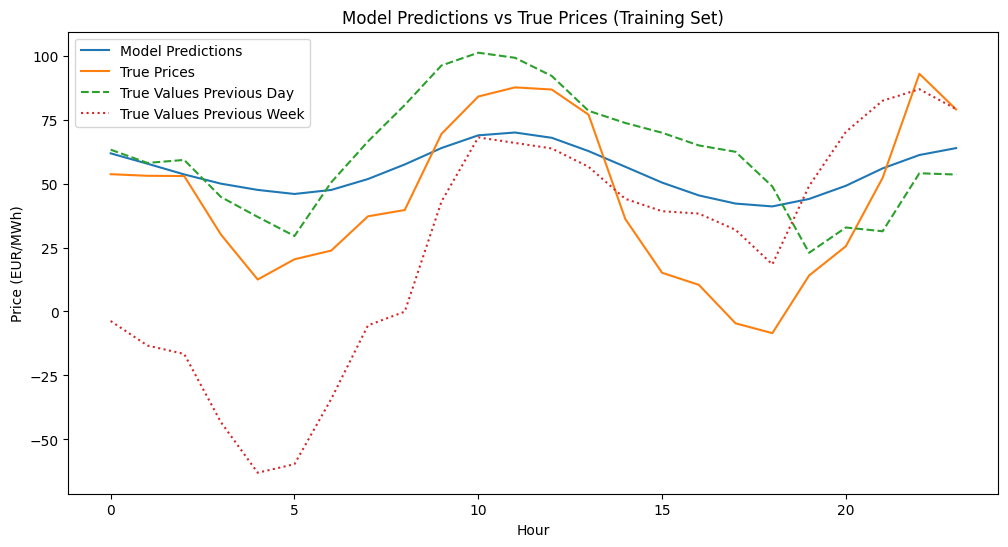

In [45]:
print("Evaluating on training set:")
eval_res_train = evaluate_model(model, X_seq_train, X_dnn_train, y_train, y_train_1d, y_train_7d, std_FR=std, mean_FR=mean, device=device)
#Plot the first 24 hours of the training set
idx=np.random.randint(168, len(y_train)-1)
plt.figure(figsize=(12,6))
plt.plot(eval_res_train['predictions'][idx], label='Model Predictions')
plt.plot(y_train[idx]*std + mean, label='True Prices')
plt.plot(y_train_1d[idx]*std + mean, label='True Values Previous Day', linestyle='--')
plt.plot(y_train_7d[idx]*std + mean, label='True Values Previous Week', linestyle=':')
plt.title('Model Predictions vs True Prices (Training Set)')
plt.xlabel('Hour')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.show()  

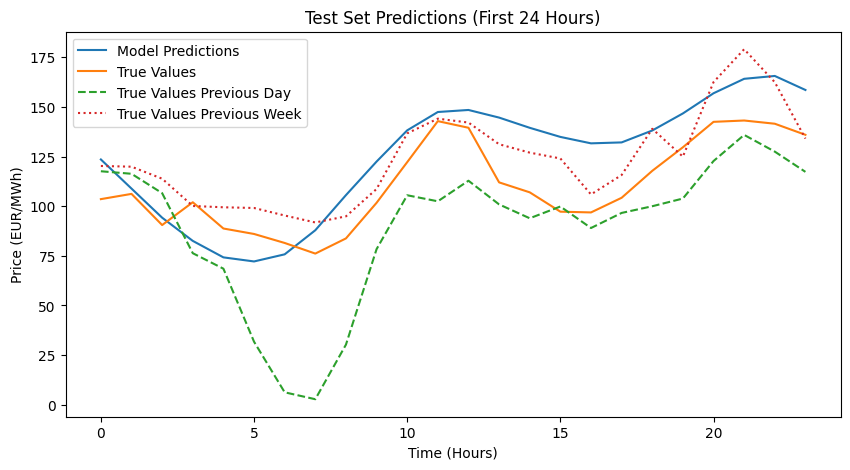

In [46]:
#Plot on the forst 24 hours of the test set
idx=np.random.randint(168, len(y_test)-1)

plt.figure(figsize=(10, 5))
plt.plot(eval_res_test['predictions'][idx], label='Model Predictions')
plt.plot(y_test[idx]*std + mean, label='True Values')
plt.plot(y_test_1d[idx]*std + mean, label='True Values Previous Day', linestyle='--')
plt.plot(y_test_7d[idx]*std + mean, label='True Values Previous Week', linestyle=':')
plt.title('Test Set Predictions (First 24 Hours)')
plt.xlabel('Time (Hours)')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.show()

In [47]:
def objective(trial):
    # --- Hyperparameters to tune ---
    hidden_size=trial.suggest_categorical("hidden_size", [64, 128, 256])
    num_layers=trial.suggest_categorical("num_layers", [1, 2, 3])
    dropout = trial.suggest_float("dropout", 0.0, 0.5)
    use_batchnorm = trial.suggest_categorical("use_batchnorm", [True, False])
    leaky_alpha = trial.suggest_float("leaky_alpha", 0.0, 0.2)
    learning_rate = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
    weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
    l1_lambda = trial.suggest_loguniform("l1_lambda", 1e-7, 1e-3)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    epochs = 20  # you can reduce for faster search

    # --- Train model ---
    MODEL, train_hist, val_hist = run_full_train(
        X_seq_train, X_dnn_train, y_train, X_seq_dev, X_dnn_dev, y_dev,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        use_batchnorm=use_batchnorm,
        leaky_alpha=leaky_alpha,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        l1_lambda=l1_lambda,
        batch_size=batch_size,
        epochs=epochs,
        verbose_freq=10
    )

    # --- Evaluate on dev set ---
    metrics = evaluate_model(MODEL, X_seq_dev, X_dnn_dev, y_dev, y_dev_1d, y_dev_7d, std_FR=normalization_params_FR["EUR/MWh"]["std"], mean_FR=normalization_params_FR["EUR/MWh"]["mean"], device=device)
    mae=metrics["MAE"]
    maem=metrics["MAEm"]
    rmae_1d=metrics["rMAE (1 day)"]  # smaller = better
    rmae_7d=metrics["rMAE (7 days)"]  # smaller = better

    return mae,maem, rmae_1d, rmae_7d
# --- Run the study ---
study = optuna.create_study(directions=["minimize","minimize","minimize","minimize"])    
study_name="FR_LMP_MLP"
study.optimize(objective, n_trials=20, timeout=None)

best_trials = study.best_trials
print(f"Found {len(best_trials)} Pareto-optimal trials.")

for t in best_trials:
    print(f"Values: {t.values}")
    print(f"Params: {t.params}")



[I 2025-11-19 05:33:56,056] A new study created in memory with name: no-name-3502ea41-244a-42af-bb42-a989f3470c3e
/tmp/ipykernel_9821/1560604406.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
/tmp/ipykernel_9821/1560604406.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
/tmp/ipykernel_9821/1560604406.py:10: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  l1_lambda = tri

Model:
RNN(
  (lstm): LSTM(10, 256, num_layers=2, batch_first=True, dropout=0.38074409979750584)
  (dropout): Dropout(p=0.38074409979750584, inplace=False)
  (fc1): Linear(in_features=256, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=24, bias=True)
  (bn_lstm): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn_fc1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (future_dense): Sequential(
    (0): Linear(in_features=216, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.17193121103264775)
    (2): Dropout(p=0.38074409979750584, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.17193121103264775)
  )
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None

[W 2025-11-19 05:34:01,254] Trial 0 failed with parameters: {'hidden_size': 256, 'num_layers': 2, 'dropout': 0.38074409979750584, 'use_batchnorm': True, 'leaky_alpha': 0.17193121103264775, 'learning_rate': 0.0017970840613402341, 'weight_decay': 1.4115507752983884e-05, 'l1_lambda': 1.4463001820577435e-07, 'batch_size': 64} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/opt/pytorch/lib/python3.12/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_9821/1560604406.py", line 15, in objective
    MODEL, train_hist, val_hist = run_full_train(
                                  ^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_9821/295177806.py", line 89, in run_full_train
    preds = model(seq_b, dnn_b)
            ^^^^^^^^^^^^^^^^^^^
  File "/opt/pytorch/lib/python3.12/site-packages/torch/nn/modules/module.py", line 1773, in _wrapped_call_impl
    re

KeyboardInterrupt: 

In [ ]:
#Hyperparameter search
dropout = np.linspace(0.0, 0.5, 5)
lr = np.logspace(-5, -3, 5)
results = {}

for d in dropout:
    for learning_rate in lr:
        print(f"Training with dropout {d} and learning rate {learning_rate}")
        model, train_hist, val_hist = run_full_train(
            X_train, y_train_FR, X_dev, y_dev_FR,
            dropout = d,
            use_batchnorm = False,
            leaky_alpha = 0.0,
            learning_rate = learning_rate,
            weight_decay = 0.0,
            l1_lambda = 0.0,
            batch_size = 128,
            train_amt = len(X_train_FR),
            epochs = 20,
            verbose_freq = 10
        )

        print("Evaluating on dev set:")
        eval_res = evaluate_model(
            model, X_dev, y_dev_FR, y_dev_FR_1d, y_dev_FR_7d, 
            std_FR, mean_FR, device=device
        )
        print("\n")

        # store clean results
        results[(d, learning_rate)] = {
            "MAE": eval_res["MAE"],
            "MAEm": eval_res["MAEm"],
            "rMAE1": eval_res["rMAE (1 day)"],
            "rMAE7": eval_res["rMAE (7 days)"],
        }

# --- find best ---
min_mae = min(v["MAE"] for v in results.values())
min_maem = min(v["MAEm"] for v in results.values())
min_rmae1 = min(v["rMAE1"] for v in results.values())
min_rmae7 = min(v["rMAE7"] for v in results.values())

best_configs_mae = [k for k,v in results.items() if v["MAE"] == min_mae]
best_configs_maem = [k for k,v in results.items() if v["MAEm"] == min_maem]
best_configs_rmae1 = [k for k,v in results.items() if v["rMAE1"] == min_rmae1]
best_configs_rmae7 = [k for k,v in results.items() if v["rMAE7"] == min_rmae7]

print(f"Best configurations for minimum MAE ({min_mae}): {best_configs_mae}")
print(f"Best configurations for minimum MAEm ({min_maem}): {best_configs_maem}")
print(f"Best configurations for minimum rMAE (1 day) ({min_rmae1}): {best_configs_rmae1}")
print(f"Best configurations for minimum rMAE (7 days) ({min_rmae7}): {best_configs_rmae7}")

Training with dropout 0.0 and learning rate 9.999999999999999e-06


NameError: name 'X_train' is not defined

In [ ]:
# ...existing code...
# This cell: build short labels, fill matrices, find minima and plot grid with metric-text colored per-minimum
# collect unique architectures and lrs (same ordering as rMAE plot)
archs = sorted({k[0] for k in results.keys()})   # dropout values
lrs   = sorted({k[1] for k in results.keys()})   # learning rates


# metrics to show in each grid cell
metric_keys = ["MAE", "MAEm", "rMAE1", "rMAE7"]


# prepare matrices for each metric and multiline text for annotations
metrics_mats = {mk: np.full((len(archs), len(lrs)), np.nan, dtype=float) for mk in metric_keys}
cell_text = np.full((len(archs), len(lrs)), "", dtype=object)

for (arch, lr) in results.keys():
    v = results[(arch, lr)]
    if isinstance(v, dict) and "eval" in v and isinstance(v["eval"], dict):
        ev = v["eval"]
    elif isinstance(v, dict) and any(k in v for k in metric_keys):
        ev = v
    else:
        ev = None

    i = archs.index(arch)   # arch is already a float
    j = lrs.index(lr)       # lr is also a float

    if ev is None:
        cell_text[i, j] = "no eval"
        continue

    # use short, unambiguous labels so rMAE (1 day) / (7 days) are distinct in the cell text
    short_labels = {
        "MAE": "MAE",
        "MAEm": "MAEm",
        "rMAE1": "rMAE1",
        "rMAE7": "rMAE7",
    }

    parts = []
    for mk in metric_keys:
        val = ev.get(mk, np.nan)
        try:
            valf = float(val)
        except Exception:
            valf = np.nan
        metrics_mats[mk][i, j] = valf
        lab = short_labels.get(mk, mk.split()[0])
        parts.append(f"{lab}:{valf:.3f}" if not np.isnan(valf) else f"{lab}:nan")
    cell_text[i, j] = "\n".join(parts)

# --- find minimum positions for each metric (ignore NaNs) ---
min_positions = {}
for mk in metric_keys:
    mat = metrics_mats[mk]
    if np.all(np.isnan(mat)):
        min_positions[mk] = []
    else:
        min_val = np.nanmin(mat)
        # positions as (row, col) tuples
        pos = list(zip(*np.where(np.isclose(mat, min_val, atol=1e-12))))
        min_positions[mk] = pos

# --- Plot grid WITHOUT heatmap, annotate every cell with 4 metrics and highlight minima ---
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(16, 8 + 0.6 * len(archs)))
ax.set_xlim(-0.5, len(lrs) - 0.5)
ax.set_ylim(len(archs) - 0.5, -0.5)  # origin at top to match previous layout
# set_xticks / set_yticks do not accept fontsize; set font size via set_xticklabels / set_yticklabels
ax.set_xticks(range(len(lrs)))
ax.set_xticklabels([f"{lr:.0e}" for lr in lrs], fontsize=16, rotation=45)
ax.set_yticks(range(len(archs)))
ax.set_yticklabels([str(a) for a in archs], fontsize=16)
ax.set_xlabel("learning rate", fontsize=16)
ax.set_ylabel("dropout", fontsize=16)

# draw light grid lines
for x in range(len(lrs) + 1):
    ax.axvline(x - 0.5, color='lightgray', linewidth=0.8)
for y in range(len(archs) + 1):
    ax.axhline(y - 0.5, color='lightgray', linewidth=0.8)

# colors for each metric's minima (kept distinct)
colors = ['red', 'blue', 'green', 'purple']
metric_colors = {mk: colors[idx % len(colors)] for idx, mk in enumerate(metric_keys)}
legend_patches = [patches.Patch(color=metric_colors[mk], label=mk) for mk in metric_keys]

# annotate every cell with the 4 metrics as separate text items, color the line if it's a metric minimum
# vertical offsets inside a cell (from top to bottom rows use negative->positive relative to center)
y_offsets = [-0.35, -0.12, 0.12, 0.35]

for i in range(len(archs)):
    for j in range(len(lrs)):
        ev_lines = cell_text[i, j].split("\n") if (cell_text[i, j] and isinstance(cell_text[i, j], str)) else []
        if not ev_lines:
            ax.text(j, i, "no eval", ha='center', va='center', fontsize=7, color='gray')
            continue

        # for each metric place a separate text entry with its own color (default black)
        for k, mk in enumerate(metric_keys):
            line = ev_lines[k] if k < len(ev_lines) else ""
            if not line:
                continue
            # default color
            txt_color = 'black'
            # if this (i,j) is one of the minima positions for this metric, color the metric text
            if (i, j) in min_positions.get(mk, []):
                txt_color = metric_colors[mk]
            ax.text(j, i + y_offsets[k], line, ha='center', va='center', fontsize=16, color=txt_color)

# place legend outside plot to the right
ax.legend(handles=legend_patches, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12, borderaxespad=0.1)

plt.tight_layout()
plt.savefig("metrics_grid_minima_text_colored.png", bbox_inches='tight')
plt.show()
# ...existing code...